> Consultas a descrição do banco aqui: https://www.kaggle.com/datasets/aravindpcoder/obesity-or-cvd-risk-classifyregressorcluster

# Descrição do dataset

### Atributos relacionados a hábitos alimentares são:
> • Frequent consumption of high caloric food (FAVC)
<br>• Frequency of consumption of vegetables (FCVC)
<br>• Number of main meals (NCP)
<br>• Consumption of food between meals (CAEC)
<br>• Consumption of water daily (CH20)
<br>• Consumption of alcohol (CALC).
<br>The attributes related with the physical condition are:
<br>• Calories consumption monitoring (SCC)
<br>• Physical activity frequency (FAF)
<br>• Time using technology devices (TUE)
<br>• Transportation used (MTRANS)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io
import numpy as np
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from IPython.display import display, HTML

# Load the uploaded CSV file
file_path = '/content/ObesityDataSet.csv'
data = pd.read_csv(file_path)

# Remoção da coluna target do dataset
data = data.drop(columns=['NObeyesdad'])

# Identificar colunas numéricas e categóricas
numerical_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
categorical_features = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

# Função PCA para plotar os clusters
def plot_clusters(X, labels, title):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels, palette="viridis", s=100, alpha=0.8)
    plt.title(title)
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.legend(title='Cluster')
    plt.show()

# Função para plotar os clusters (usando t-SNE)
def plot_clusters_tsne(X, labels, title):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels, palette="viridis", s=100, alpha=0.8)
    plt.title(title)
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend(title='Cluster')
    plt.show()

In [ ]:
# Análise inicial do dataset (valores faltantes, médias de valores, máximos e mínimos)

# Exibir data.info() e data.isnull().sum() lado a lado, com head() e describe() abaixo
info_buf = []
# Use StringIO to capture the output of data.info()
buffer = io.StringIO()
data.info(buf=buffer)
info_str = buffer.getvalue()

# Exibir os resultados
display(HTML(f"<div style='display: flex;'>"
             f"<div style='margin-right: 50px;'><pre>{info_str}</pre></div>"
             f"<div><pre><h3>Exibição de valores nulos no dataset:</h3>\n{data.isnull().sum().to_string()}</pre></div>" # Título adicionado
             f"</div>"))

# Exibir data.head() e data.describe() como está
display(data.head(), data.describe())

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


# Análise de Dados

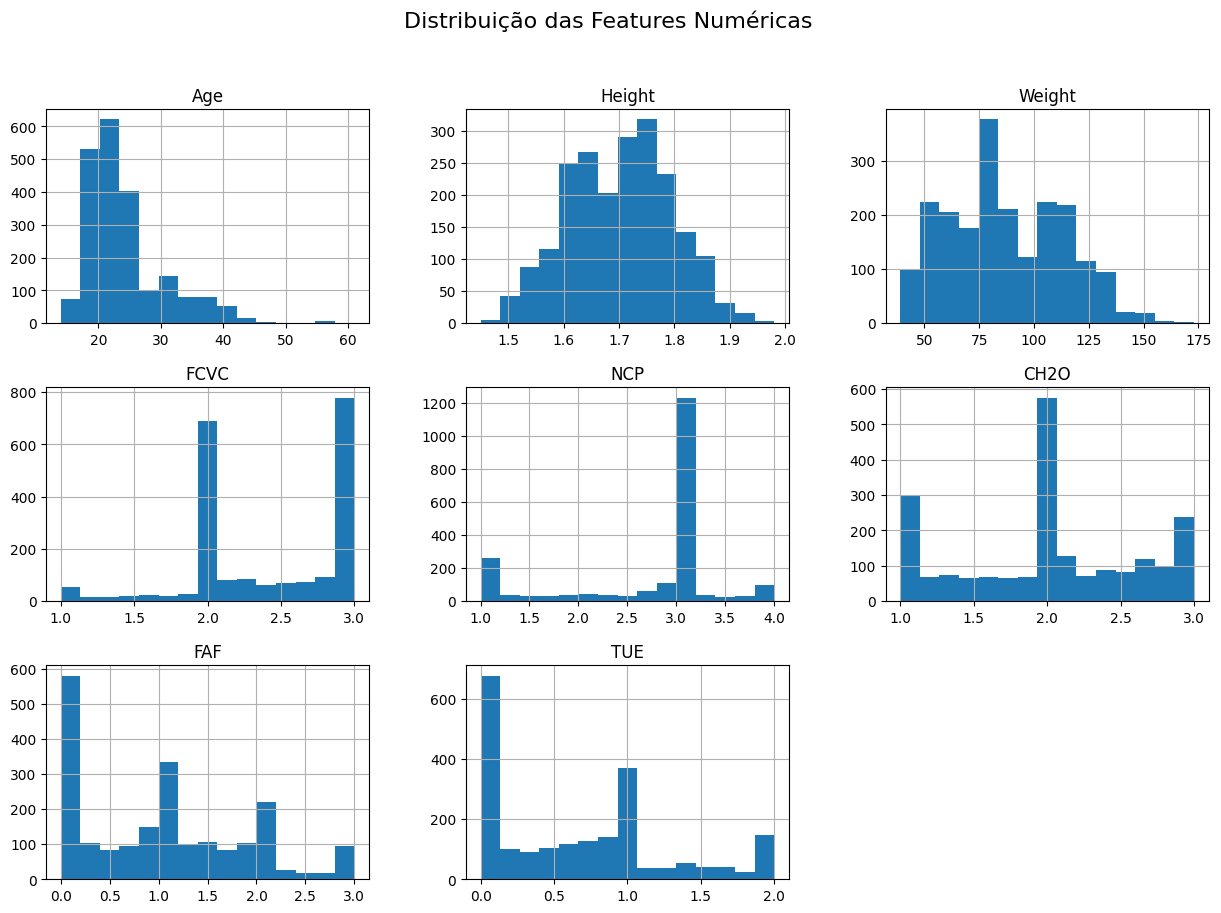

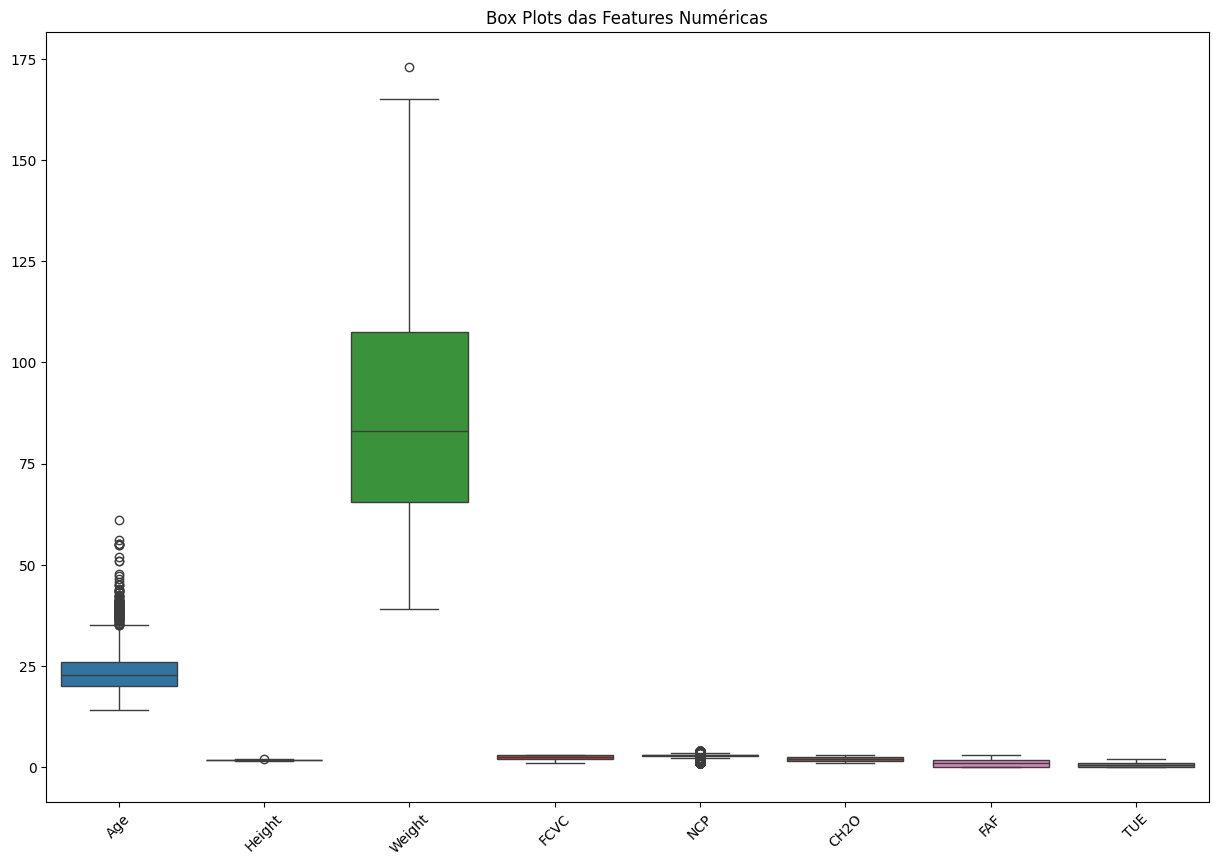

In [ ]:
## -> Plotagem da distribuição das features numéricas

# Histogramas
data[numerical_features].hist(bins=15, figsize=(15, 10))
plt.suptitle('Distribuição das Features Numéricas', fontsize=16)
plt.show()

# Box plots
plt.figure(figsize=(15, 10))
sns.boxplot(data=data[numerical_features])
plt.xticks(rotation=45)
plt.title('Box Plots das Features Numéricas')
plt.show()

##Análise dos Histogramas
  **Os histogramas mostram a distribuição de frequência para cada feature numérica. Cada barra representa a frequência de dados dentro de um intervalo específico de valores.**

> **Age**: A maioria das pessoas tem entre 18 e 30 anos, com uma distribuição ligeiramente inclinada para a esquerda, indicando menos indivíduos mais velhos.

> **Height**: Os dados são aproximadamente normalmente distribuídos em torno de 1,7 metros, com a maioria das pessoas entre 1,6 e 1,8 metros.

> **Weight**: A distribuição tem múltiplos picos (multimodal), sugerindo diferentes grupos ou tipos de peso corporal.

> **FCVC (Frequency of consumption of vegetables)**: Mostra picos em valores específicos (1, 2, e 3), indicando categorias discretas de consumo de vegetais.

> **NCP (Number of main meals)**: Similar ao FCVC, com picos em valores discretos (principalmente em 3), sugerindo que a maioria das pessoas consome três refeições principais por dia.

> **CH2O (Consumption of water daily)**: Outro exemplo de dados com picos em valores específicos, indicando diferentes níveis de consumo de água.

> **FAF (Physical activity frequency) e TUE (Time using technology devices)**: Ambos têm distribuições variadas com alguns picos, indicando diferentes níveis de atividade física e uso de tecnologia.

###O que isso nos diz?
> As variáveis como FCVC, NCP, e CH2O, que mostram picos em valores específicos, podem precisar ser tratadas como categóricas ou ordenadas.
Outliers podem estar presentes, especialmente em variáveis como Weight, onde a cauda à direita é longa.

##2. Análise da Matriz de Correlação##

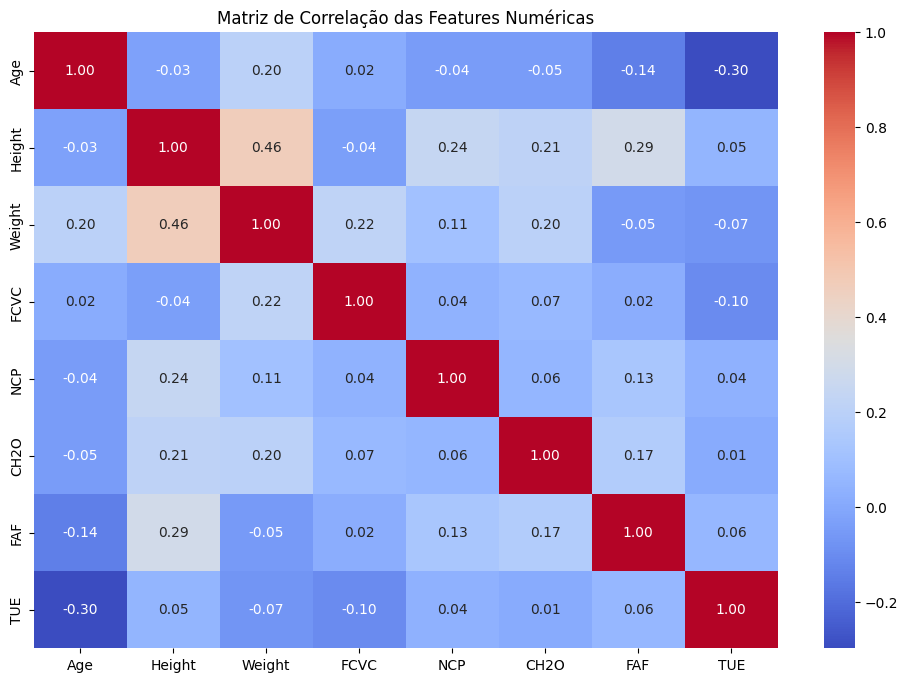

In [ ]:
## -> Plotagem da matriz de correlação

# Matriz de correlação
plt.figure(figsize=(12, 8))
correlation_matrix = data[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Features Numéricas')
plt.show()

###Entendendo a visualização da matriz

A matriz de correlação mostra como as variáveis estão relacionadas umas com as outras. Valores próximos a 1 ou -1 indicam uma forte correlação positiva ou negativa, respectivamente.

###Correlações Positivas Fortes:
> **Height e Weight**: 0,46, indicando que pessoas mais altas tendem a pesar mais.

###Correlações Negativas:
> **Age e TUE**: -0,30, indicando que pessoas mais jovens tendem a usar mais dispositivos tecnológicos.

###O que isso nos diz?

> Features fortemente correlacionadas podem indicar redundância; no entanto, nenhuma das correlações é extremamente alta, então todas as variáveis ainda são úteis.

> Algumas variáveis mostram pequenas correlações que podem ser exploradas para entender comportamentos e hábitos específicos dos indivíduos.

---

2. Análise de Outliers

In [ ]:
from scipy import stats

# Calcular z-scores
z_scores = stats.zscore(data[numerical_features])

# Identificar outliers com base em z-scores (por exemplo, z > 3)
outliers_indices = (z_scores > 3)

# Exibir outliers para cada feature
for feature in numerical_features:
    feature_outliers = data[feature][outliers_indices[feature]]
    print(f"Outliers em {feature}:")
    print(feature_outliers)
    print("-" * 30)

Outliers em Age:
21      52.000000
92      55.000000
133     61.000000
137     44.000000
161     55.000000
169     45.000000
232     51.000000
252     56.000000
492     45.000000
1013    55.246250
1034    50.832559
1063    45.000000
1088    55.137881
1101    46.491859
1158    55.022494
1179    47.706100
1208    45.821267
1215    43.604901
1267    43.510672
1286    47.283374
1305    43.591999
1386    43.719395
1387    43.376340
1490    43.726081
Name: Age, dtype: float64
------------------------------
Outliers em Height:
Series([], Name: Height, dtype: float64)
------------------------------
Outliers em Weight:
344    173.0
Name: Weight, dtype: float64
------------------------------
Outliers em FCVC:
Series([], Name: FCVC, dtype: float64)
------------------------------
Outliers em NCP:
Series([], Name: NCP, dtype: float64)
------------------------------
Outliers em CH2O:
Series([], Name: CH2O, dtype: float64)
------------------------------
Outliers em FAF:
Series([], Name: FAF, dtype: f

--> Nenhum desses são outliers de fato


---



# Aplicação das técnicas de clusterização

## 1. K-Means

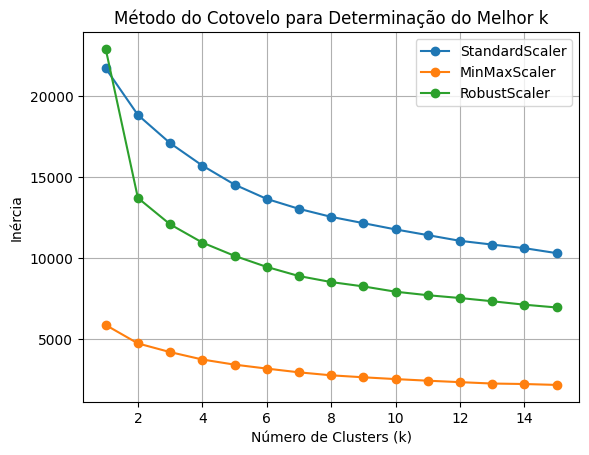

Melhores Parâmetros Após Nova Otimização:
Scaler: MinMaxScaler
n_clusters: 6
n_init: 10
Silhouette Score: 0.26325318344567783
Davies-Bouldin Score: 1.5342369666610354
Calinski-Harabasz Score: 358.9825549475565
Silhouette Score para K-Means++: 0.26325318344567783
Davies-Bouldin Score para K-Means++: 1.5342369666610354
Calinski-Harabasz Score para K-Means++: 358.9825549475565


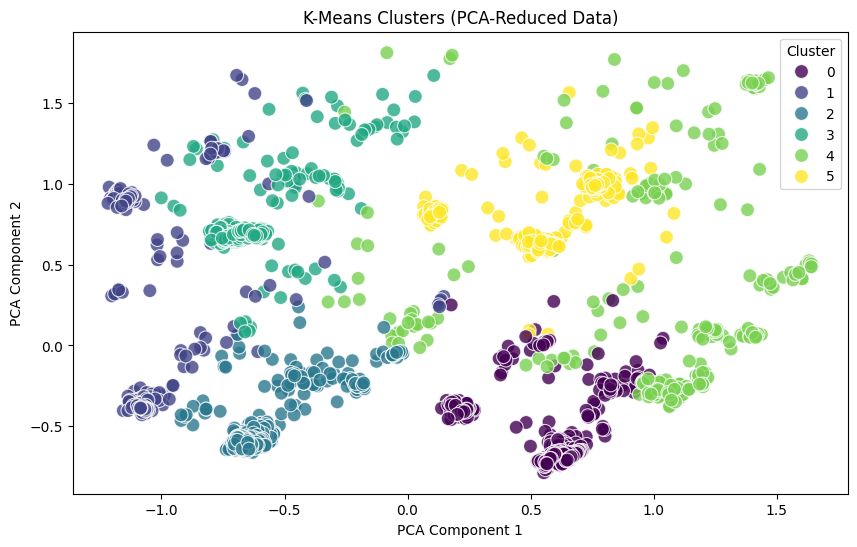

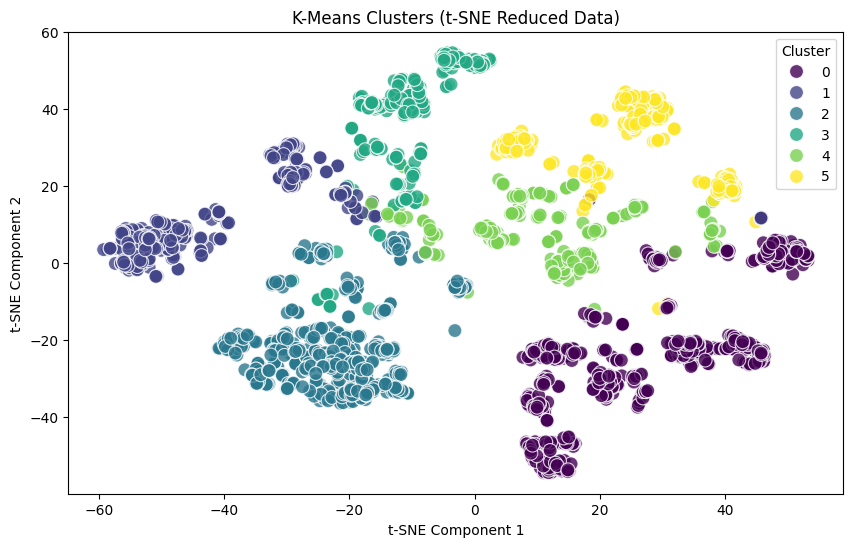

In [ ]:
# Função para o Método do Cotovelo
def elbow_method(data, numerical_features, categorical_features, max_k=15):
    scalers = {
        'StandardScaler': StandardScaler(),
        'MinMaxScaler': MinMaxScaler(),
        'RobustScaler': RobustScaler()
    }

    inertia_results = {}

    for scaler_name, scaler in scalers.items():
        # Criar preprocessor com o scaler atual
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', scaler, numerical_features),
                ('cat', OneHotEncoder(), categorical_features)
            ])

        inertia = []
        k_values = range(1, max_k + 1)

        for k in k_values:
            # Criar pipeline com o preprocessor e K-Means
            pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                       ('kmeans', KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10))])

            # Ajustar o pipeline aos dados
            pipeline.fit(data)

            # Extrair a inércia do K-Means
            inertia.append(pipeline.named_steps['kmeans'].inertia_)

        inertia_results[scaler_name] = inertia

        # Plotar o gráfico de inércia para cada scaler
        plt.plot(k_values, inertia, marker='o', label=f"{scaler_name}")

    plt.title('Método do Cotovelo para Determinação do Melhor k')
    plt.xlabel('Número de Clusters (k)')
    plt.ylabel('Inércia')
    plt.legend()
    plt.grid(True)
    plt.show()

    return inertia_results

# Função para otimizar o número de clusters e parâmetros do K-Means
def optimize_kmeans(data, numerical_features, categorical_features, n_clusters):
    scalers = {
        'StandardScaler': StandardScaler(),
        'MinMaxScaler': MinMaxScaler(),
        'RobustScaler': RobustScaler()
    }

    results = []

    for scaler_name, scaler in scalers.items():
        # Criar preprocessor com o scaler atual
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', scaler, numerical_features),
                ('cat', OneHotEncoder(), categorical_features)
            ])

        for n_init in [10, 20, 30]:
            # Criar pipeline com o preprocessor e K-Means
            pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                       ('kmeans', KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=n_init))])

            # Ajustar o pipeline aos dados
            pipeline.fit(data)

            # Extrair as labels e calcular as métricas
            kmeans_labels = pipeline.named_steps['kmeans'].labels_
            X_scaled = pipeline.named_steps['preprocessor'].transform(data)

            silhouette_avg = silhouette_score(X_scaled, kmeans_labels)
            davies_bouldin_avg = davies_bouldin_score(X_scaled, kmeans_labels)
            calinski_harabasz_avg = calinski_harabasz_score(X_scaled, kmeans_labels)

            results.append({
                'scaler': scaler_name,
                'n_clusters': n_clusters,
                'n_init': n_init,
                'silhouette_score': silhouette_avg,
                'davies_bouldin_score': davies_bouldin_avg,
                'calinski_harabasz_score': calinski_harabasz_avg
            })

    # Encontrar a melhor combinação de parâmetros com base no Silhouette Score
    best_result = max(results, key=lambda x: x['silhouette_score'])

    return best_result, results

# Executar o método do cotovelo para determinar o melhor k
elbow_results = elbow_method(data, numerical_features, categorical_features, max_k=15)

# Analisando o resultado do método do cotovelo, escolha o melhor valor de k
chosen_k = 6  # Exemplo; ajuste baseado na análise do cotovelo

# Repetir o processo de otimização para o novo valor de k escolhido
best_params, all_results = optimize_kmeans(data, numerical_features, categorical_features, n_clusters=chosen_k)

print("Melhores Parâmetros Após Nova Otimização:")
print(f"Scaler: {best_params['scaler']}")
print(f"n_clusters: {best_params['n_clusters']}")
print(f"n_init: {best_params['n_init']}")
print(f"Silhouette Score: {best_params['silhouette_score']}")
print(f"Davies-Bouldin Score: {best_params['davies_bouldin_score']}")
print(f"Calinski-Harabasz Score: {best_params['calinski_harabasz_score']}")

# Criar pipeline com o melhor scaler e n_init
scaler = eval(f"{best_params['scaler']}()")
preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, numerical_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('kmeans', KMeans(n_clusters=best_params['n_clusters'], init='k-means++', random_state=42, n_init=best_params['n_init']))])

# Ajustar o pipeline aos dados
pipeline.fit(data)

# Extrair as labels
kmeans_labels = pipeline.named_steps['kmeans'].labels_

# Calcular as métricas de avaliação
X_scaled = pipeline.named_steps['preprocessor'].transform(data)
silhouette_avg = silhouette_score(X_scaled, kmeans_labels)
davies_bouldin_avg = davies_bouldin_score(X_scaled, kmeans_labels)
calinski_harabasz_avg = calinski_harabasz_score(X_scaled, kmeans_labels)

# Exibir os resultados finais
print(f"Silhouette Score para K-Means++: {silhouette_avg}")
print(f"Davies-Bouldin Score para K-Means++: {davies_bouldin_avg}")
print(f"Calinski-Harabasz Score para K-Means++: {calinski_harabasz_avg}")

# Redução de dimensionalidade com PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plotar os clusters usando PCA
plot_clusters(X_pca, kmeans_labels, 'K-Means Clusters (PCA-Reduced Data)')

# Redução de dimensionalidade com t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Plotar os clusters usando t-SNE
plot_clusters_tsne(X_tsne, kmeans_labels, 'K-Means Clusters (t-SNE Reduced Data)')

## 2. DBScan

Silhouette Score para DBScan: -0.0479973001252731
Davies-Bouldin Score para DBScan: 1.325492224993888
Calinski-Harabasz Score para DBScan: 14.295885149265352


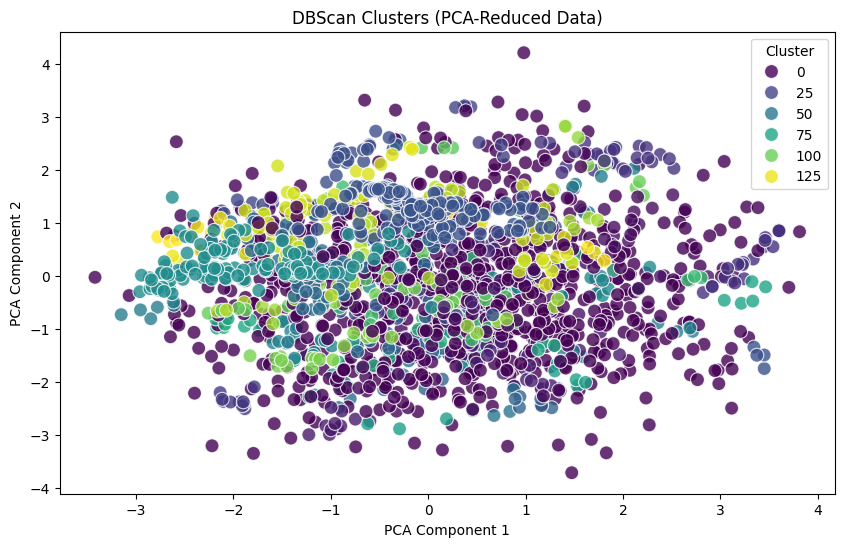

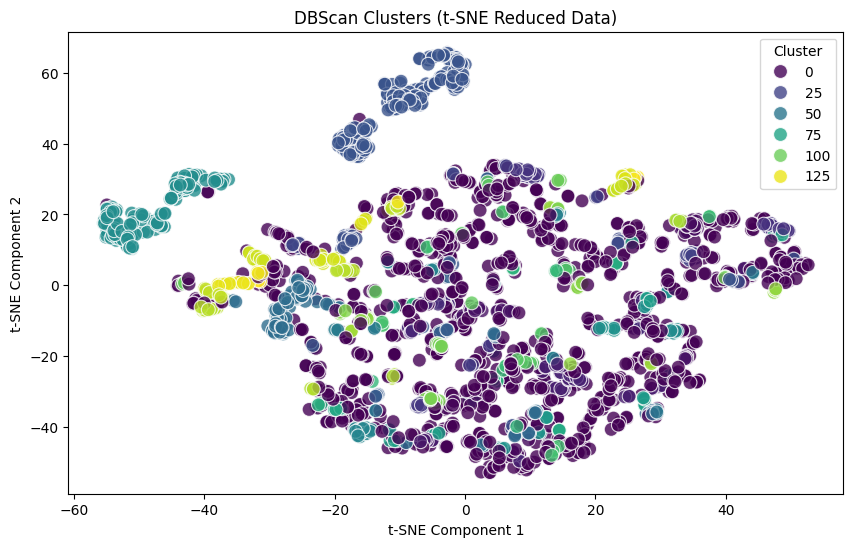

In [3]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler

# Normalização dos dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[numerical_features])

# DBScan
dbscan = DBSCAN(eps=0.7, min_samples=3)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Calcular as métricas de avaliação
silhouette_avg = silhouette_score(X_scaled, dbscan_labels)
davies_bouldin_avg = davies_bouldin_score(X_scaled, dbscan_labels)
calinski_harabasz_avg = calinski_harabasz_score(X_scaled, dbscan_labels)

# Exibir os resultados
print(f"Silhouette Score para DBScan: {silhouette_avg}")
print(f"Davies-Bouldin Score para DBScan: {davies_bouldin_avg}")
print(f"Calinski-Harabasz Score para DBScan: {calinski_harabasz_avg}")

# Loop para decidir melhor argumento de inicialização para DBScan
"""
for eps in [0.3, 0.5, 0.7]:
    for min_samples in [3, 5, 10]:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan_labels = dbscan.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, dbscan_labels)
        print(f'DBScan - eps: {eps}, min_samples: {min_samples}, Silhouette Score: {score}')
"""

#   Função para plotar os clusters
def plot_clusters(X, labels, title):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels, palette="viridis", s=100, alpha=0.8)
    plt.title(title)
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.legend(title='Cluster')
    plt.show()

# Aplicar PCA para redução de dimensionalidade
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualizar os clusters DBScan com PCA
plot_clusters(X_pca, dbscan_labels, 'DBScan Clusters (PCA-Reduced Data)')

# Aplicar t-SNE para redução de dimensionalidade
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Função para plotar os clusters (usando t-SNE)
def plot_clusters_tsne(X, labels, title):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels, palette="viridis", s=100, alpha=0.8)
    plt.title(title)
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend(title='Cluster')
    plt.show()

# Visualizar os clusters DBScan com t-SNE
plot_clusters_tsne(X_tsne, dbscan_labels, 'DBScan Clusters (t-SNE Reduced Data)')

##3. Clusterização Hierárquica

Melhores Parâmetros para Clusterização Hierárquica (Aperfeiçoado):
Scaler: RobustScaler
Linkage: complete
n_clusters: 3
Silhouette Score: 0.37600395039723444
Davies-Bouldin Score: 1.0150165104272482
Calinski-Harabasz Score: 705.472050243718


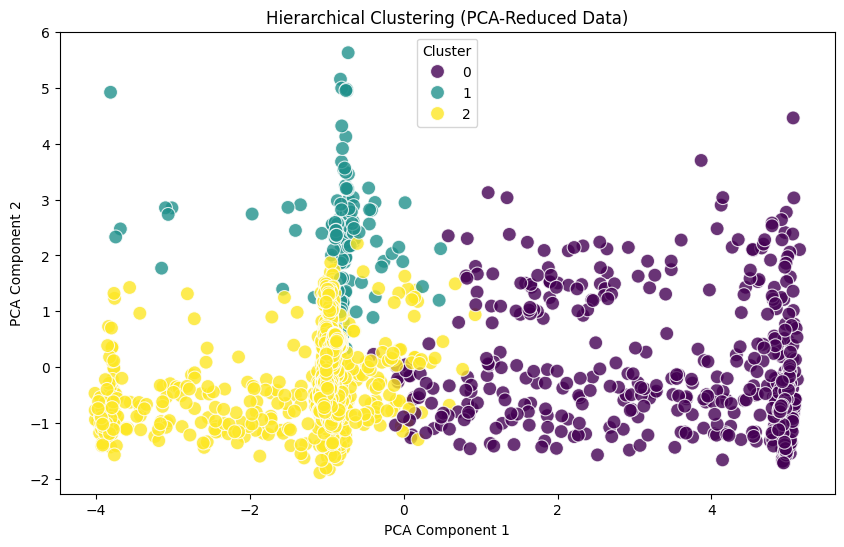

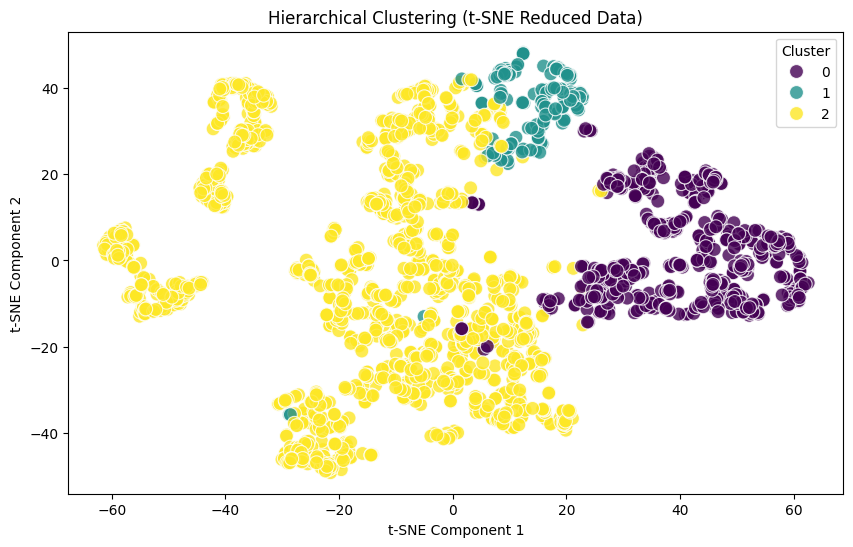

In [ ]:
# Função para otimizar os parâmetros da Clusterização Hierárquica
def optimize_hierarchical_clustering(data, numerical_features, categorical_features):
    scalers = {
        'StandardScaler': StandardScaler(),
        'MinMaxScaler': MinMaxScaler(),
        'RobustScaler': RobustScaler()
    }

    linkages = ['ward', 'complete', 'average']
    results = []

    for scaler_name, scaler in scalers.items():
        for linkage in linkages:
            for n_clusters in range(3, 8):  # Experimentar de 3 a 7 clusters
                # Preprocessamento
                preprocessor = ColumnTransformer(
                    transformers=[
                        ('num', scaler, numerical_features),
                        ('cat', OneHotEncoder(), categorical_features)
                    ])

                # Pipeline de Clusterização Hierárquica
                pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                           ('clustering', AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage))])

                # Ajuste aos dados
                pipeline.fit(data)

                # Extração das labels
                labels = pipeline.named_steps['clustering'].labels_

                # Transformação dos dados para cálculo das métricas
                X_scaled = pipeline.named_steps['preprocessor'].transform(data)

                # Avaliação das métricas
                silhouette_avg = silhouette_score(X_scaled, labels)
                davies_bouldin_avg = davies_bouldin_score(X_scaled, labels)
                calinski_harabasz_avg = calinski_harabasz_score(X_scaled, labels)

                results.append({
                    'scaler': scaler_name,
                    'linkage': linkage,
                    'n_clusters': n_clusters,
                    'silhouette_score': silhouette_avg,
                    'davies_bouldin_score': davies_bouldin_avg,
                    'calinski_harabasz_score': calinski_harabasz_avg
                })

    # Encontrar a melhor combinação
    best_result = max(results, key=lambda x: x['silhouette_score'])

    return best_result, results

# Otimizar os parâmetros da Clusterização Hierárquica
best_params, all_results = optimize_hierarchical_clustering(data, numerical_features, categorical_features)

print("Melhores Parâmetros para Clusterização Hierárquica (Aperfeiçoado):")
print(f"Scaler: {best_params['scaler']}")
print(f"Linkage: {best_params['linkage']}")
print(f"n_clusters: {best_params['n_clusters']}")
print(f"Silhouette Score: {best_params['silhouette_score']}")
print(f"Davies-Bouldin Score: {best_params['davies_bouldin_score']}")
print(f"Calinski-Harabasz Score: {best_params['calinski_harabasz_score']}")

# Normalização dos dados usando o melhor scaler
scaler = eval(f"{best_params['scaler']}()")
X_scaled = scaler.fit_transform(data[numerical_features])

# Clusterização Hierárquica com os melhores parâmetros
agg_clustering = AgglomerativeClustering(n_clusters=best_params['n_clusters'], linkage=best_params['linkage'])
agg_labels = agg_clustering.fit_predict(X_scaled)

# Redução de dimensionalidade com PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plotar os clusters usando PCA
plot_clusters(X_pca, agg_labels, 'Hierarchical Clustering (PCA-Reduced Data)')

# Redução de dimensionalidade com t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Plotar os clusters usando t-SNE
plot_clusters_tsne(X_tsne, agg_labels, 'Hierarchical Clustering (t-SNE Reduced Data)')